In [ ]:
import sys
print(sys.executable)
print(sys.prefix)

# Just ensure you are using the right venv helps with cross contributor portability.
# the expected output should be something like 
# /Users/rishavbhagat/developer/ChartQA-IIITH/.venv/bin/python
# /Users/rishavbhagat/developer/ChartQA-IIITH/.venv

/Users/rishavbhagat/developer/ChartQA-IIITH/.venv/bin/python
/Users/rishavbhagat/developer/ChartQA-IIITH/.venv


# The begining of the basic data set exploration

Herin we start by having a look at the testing data only, 


In [14]:
PATHS = ["../datasets/HuggingFaceM4/ChartQA/data/train-00000-of-00003-49492f364babfa44.parquet", 
        "datasets/HuggingFaceM4/ChartQA/data/train-00001-of-00003-7302bae5e425bbc7.parquet",
        "datasets/HuggingFaceM4/ChartQA/data/train-00002-of-00003-194c9400785577a2.parquet" 
        ]

In [ ]:
# import os
# import sys

# # 1. Print the location of the Python interpreter executable
# print("Python Executable:", sys.executable)

# # 2. Print the current working directory (where Python looks for relative paths)
# print("Current Working Directory:", os.getcwd())

# # 3. List files in the current working directory to see what is visible
# print("Files in current directory:", os.listdir("../datasets/HuggingFaceM4/ChartQA/data"))


Python Executable: /Users/rishavbhagat/developer/ChartQA-IIITH/.venv/bin/python
Current Working Directory: /Users/rishavbhagat/developer/ChartQA-IIITH/data_exploration
Files in current directory: ['train-00002-of-00003-194c9400785577a2.parquet', 'test-00000-of-00001-e2cd0b7a0f9eb20d.parquet', 'train-00000-of-00003-49492f364babfa44.parquet', 'val-00000-of-00001-0f11003c77497969.parquet', 'train-00001-of-00003-7302bae5e425bbc7.parquet']


In [15]:
import pandas as pd

# Load only the first few rows to inspect the structure

df_preview = pd.read_parquet(PATHS[0], engine="pyarrow").head()
print(df_preview.info())
print(df_preview.columns)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   image             5 non-null      object
 1   query             5 non-null      object
 2   label             5 non-null      object
 3   human_or_machine  5 non-null      int64 
dtypes: int64(1), object(3)
memory usage: 288.0+ bytes
None
Index(['image', 'query', 'label', 'human_or_machine'], dtype='object')


In [22]:
import io
import matplotlib.pyplot as plt
from PIL import Image

def decode_chart_image(row, image_col='image'):
    val = row[image_col]
    if isinstance(val, dict) and 'bytes' in val:
        return Image.open(io.BytesIO(val['bytes']))
    elif isinstance(val, bytes):
        return Image.open(io.BytesIO(val))
    elif isinstance(val, str):
        return Image.open(val)
    else:
        raise ValueError("Unsupported image column format. Ensure it contains bytes or paths.")




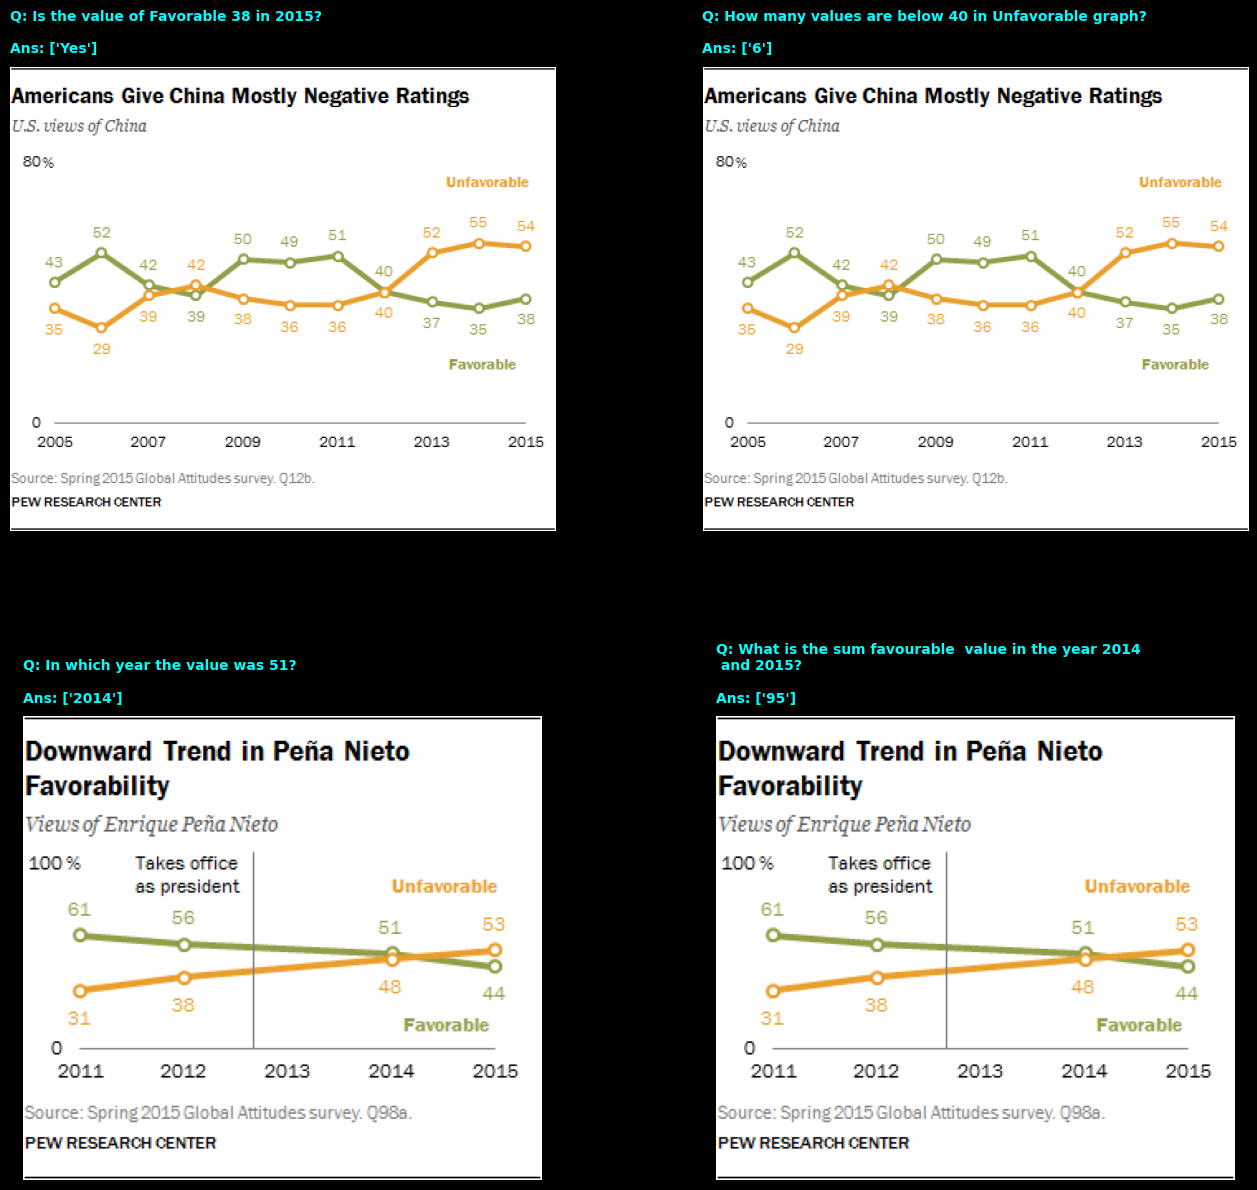

In [23]:
# Select 4 samples to inspect closely
sample_df = df.head(4)

# Set up a grid layout (2 rows, 2 columns) with a dark facecolor
fig, axes = plt.subplots(2, 2, figsize=(14, 12), facecolor='black')
axes = axes.flatten()

for i, (_, row) in enumerate(sample_df.iterrows()):
    ax = axes[i]
    ax.set_facecolor('black')
    
    # Load and display chart image
    img = decode_chart_image(row)
    ax.imshow(img)
    ax.axis('off')
    
    # Extract query text and target answer label safely
    # Adjust string keys if your columns are named 'question' or 'answer'
    query_text = row.get('query', row.get('question', 'No Query Found'))
    label_text = row.get('label', row.get('answer', 'No Label Found'))
    
    # Wrap long questions so they fit nicely as titles
    wrapped_query = "\n".join([query_text[j:j+50] for j in range(0, len(query_text), 50)])
    
    # Title display (Cyan for query text, Green for ground truth label)
    ax.set_title(
        f"Q: {wrapped_query}\n\nAns: {label_text}", 
        color='#00ffff', 
        fontsize=10, 
        loc='left', 
        pad=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.subplots_adjust(hspace=0.4) # Add space for multi-line text titles
plt.show()
